In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# A4: Generative Models

In this lab, we implement and compare **three generative model families** that define the history of AI image generation:

1. **GAN** (Generative Adversarial Network) — adversarial training between a generator and discriminator on MNIST
2. **CycleGAN** — unpaired image-to-image translation on face datasets; test with your own photo
3. **DDPM** (Denoising Diffusion Probabilistic Model) — iterative denoising; the backbone of Stable Diffusion

### Why is Image Generation Hard?

To generate a realistic image, a model must learn the full probability distribution of natural images — an astronomically high-dimensional space. A 32×32 RGB image has **3,072 pixel values**, each ranging 0–255. Yet somehow, a neural network must learn to sample from the tiny subset that looks like real photographs.

Three major approaches have dominated:

| Approach | Core Idea | Pros | Cons |
|---|---|---|---|
| **VAE** | Encode to latent space + decode | Stable, smooth latent | Blurry outputs |
| **GAN** | Train generator vs discriminator | Fast, sharp images | Unstable, mode collapse |
| **Diffusion** | Iteratively denoise from noise | High quality, diverse | Slow sampling |

![Generative Models Overview](img/generative_overview.png)

In [2]:
!pip install torch torchvision numpy matplotlib tqdm Pillow requests

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import os, random, time
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(42)
# os.makedirs('/content/drive/MyDrive/AIT/RTML/A4-Generative-Models/saved', exist_ok=True)
# os.makedirs('/content/drive/MyDrive/AIT/RTML/A4-Generative-Models/data/celeba', exist_ok=True)

Using device: cuda


---
## Part 1: GAN — Generative Adversarial Network

### Before GAN: the VAE approach — "compress, then reconstruct"

Before adversarial training existed, the standard way to generate images was the **Variational Autoencoder (VAE)**: encode an image into a compressed latent vector `z`, then decode `z` back into an image. Training just minimizes how different the reconstruction is from the original:

$$\mathcal{L}_{VAE} = \underbrace{\|x - \hat{x}\|^2}_{\text{reconstruction loss}} + \underbrace{D_{KL}\big(q(z|x) \,\|\, p(z)\big)}_{\text{regularize latent space}}$$

The first term (`recon_loss`) is just pixel-wise MSE between the input `x` and the reconstructed `x̂` — "did I rebuild the same image I started with?"

**The problem: blurry images.** Because `recon_loss` is an *average* over pixels, the VAE is rewarded for hedging — when uncertain about a sharp edge or fine texture, the safest bet (lowest expected MSE) is to output something blurry/averaged rather than commit to one sharp possibility. The model is never told "this pixel pattern looks fake" — it only ever sees "how far off was I, on average."

### The idea of GAN: from "compression" to "catching fakes"

GAN drops the reconstruction loss entirely. Instead of asking a decoder to rebuild a *specific* input image, GAN asks a separate network — the **discriminator** — to judge whether an image looks real or fake. The generator never sees pixel-by-pixel targets; it only gets feedback on whether it fooled the discriminator.

> **VAE asks:** "How close is my reconstruction to the original, pixel by pixel?" (compression/reconstruction)
> **GAN asks:** "Would a judge mistake this for a real photo?" (adversarial detection)

This shift is what fixes the blur: a discriminator can penalize *any* sharp-but-wrong detail as "fake," while MSE reconstruction loss has no way to penalize blur itself — blur is often the MSE-optimal answer.

### The GAN Revolution (2014)

Ian Goodfellow introduced GANs in 2014 with a simple but powerful idea: instead of defining a loss function explicitly, let a **discriminator network** learn the loss. The generator and discriminator play a minimax game — the generator tries to fool the discriminator, and the discriminator tries to catch fakes.

$$\min_G \max_D \; \mathbb{E}_{x \sim p_{data}}[\log D(x)] + \mathbb{E}_{z \sim p_z}[\log(1 - D(G(z)))]$$

**GAN Training Flow** (Google ML):

![GAN Workflow](img/gan_workflow.svg)

**DCGAN Generator Architecture** (Radford et al., 2015) — noise z → transposed convolutions → image:

![DCGAN Generator](img/DCGAN.png)

**Mode Collapse:** A common failure mode — G learns to produce only a few types of outputs, ignoring most of the data distribution.

We train a fully-connected GAN on MNIST below.

In [6]:
# ============================================================
#  Part 1 — GAN: Model Architecture
# ============================================================

class Generator(nn.Module):
    """Fully-connected generator: noise z -> fake 28x28 image."""
    def __init__(self, z_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(z_dim, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    """Fully-connected discriminator: image -> real/fake probability."""
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

In [7]:
# --- MNIST Data for GAN ---
gan_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1, 1]
])
gan_mnist = torchvision.datasets.MNIST('/content/drive/MyDrive/AIT/RTML/A4-Generative-Models/data', train=True, download=True, transform=gan_transform)
gan_loader = DataLoader(gan_mnist, batch_size=128, shuffle=True, num_workers=2)
print(f"MNIST: {len(gan_mnist)} training images")

MNIST: 60000 training images


In [8]:
# --- GAN Setup ---
Z_DIM = 100
G_gan = Generator(Z_DIM).to(device)
D_gan = Discriminator().to(device)

opt_G = torch.optim.Adam(G_gan.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D_gan.parameters(), lr=2e-4, betas=(0.5, 0.999))
criterion = nn.BCELoss()

fixed_noise = torch.randn(64, Z_DIM).to(device)

def show_generated(model, noise, epoch):
    model.eval()
    with torch.no_grad():
        fake = model(noise).view(-1, 1, 28, 28).cpu()
    grid = torchvision.utils.make_grid(fake, nrow=8, normalize=True)
    plt.figure(figsize=(8, 8))
    plt.imshow(grid.permute(1, 2, 0))
    plt.title(f'Epoch {epoch} — Generated MNIST')
    plt.axis('off')
    plt.show()
    model.train()

GAN Epoch 1/20: 100%|██████████| 469/469 [00:07<00:00, 64.86it/s]


Epoch 01 | G: 1.865 | D: 0.833 | 7.2s


GAN Epoch 2/20: 100%|██████████| 469/469 [00:06<00:00, 67.40it/s]


Epoch 02 | G: 3.248 | D: 0.573 | 7.0s


GAN Epoch 3/20: 100%|██████████| 469/469 [00:06<00:00, 71.40it/s]


Epoch 03 | G: 2.824 | D: 0.566 | 6.6s


GAN Epoch 4/20: 100%|██████████| 469/469 [00:06<00:00, 70.34it/s]


Epoch 04 | G: 3.453 | D: 0.350 | 6.7s


GAN Epoch 5/20: 100%|██████████| 469/469 [00:06<00:00, 73.04it/s]


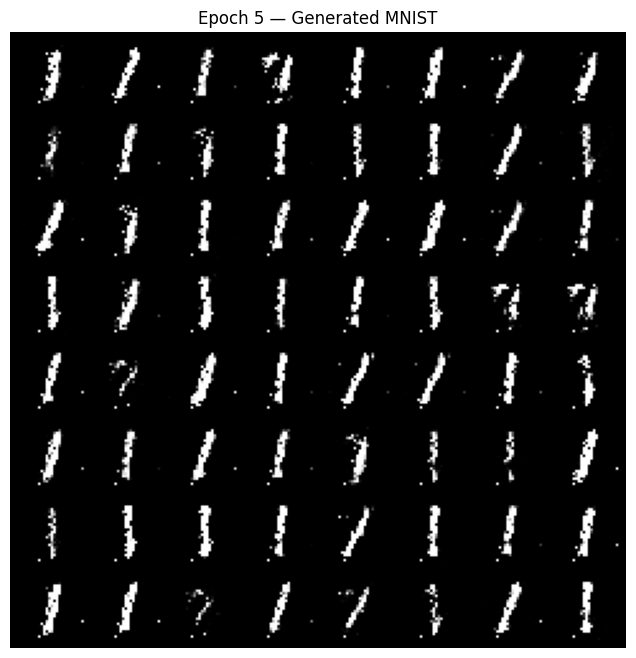

Epoch 05 | G: 3.808 | D: 0.251 | 6.4s


GAN Epoch 6/20: 100%|██████████| 469/469 [00:06<00:00, 70.07it/s]


Epoch 06 | G: 3.218 | D: 0.341 | 6.7s


GAN Epoch 7/20: 100%|██████████| 469/469 [00:06<00:00, 71.00it/s]


Epoch 07 | G: 3.181 | D: 0.355 | 6.6s


GAN Epoch 8/20: 100%|██████████| 469/469 [00:06<00:00, 69.20it/s]


Epoch 08 | G: 2.615 | D: 0.472 | 6.8s


GAN Epoch 9/20: 100%|██████████| 469/469 [00:07<00:00, 66.51it/s]


Epoch 09 | G: 2.335 | D: 0.561 | 7.1s


GAN Epoch 10/20: 100%|██████████| 469/469 [00:06<00:00, 70.49it/s]


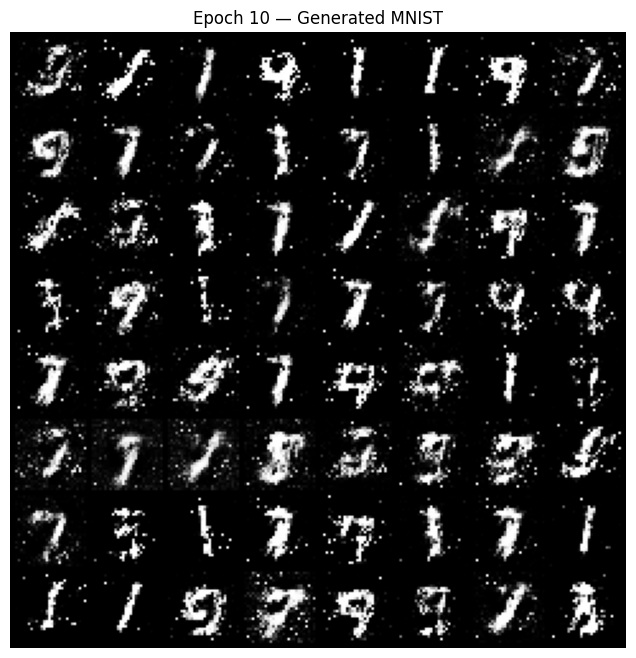

Epoch 10 | G: 1.926 | D: 0.712 | 6.7s


GAN Epoch 11/20: 100%|██████████| 469/469 [00:06<00:00, 69.55it/s]


Epoch 11 | G: 1.750 | D: 0.785 | 6.7s


GAN Epoch 12/20: 100%|██████████| 469/469 [00:06<00:00, 68.76it/s]


Epoch 12 | G: 1.586 | D: 0.870 | 6.8s


GAN Epoch 13/20: 100%|██████████| 469/469 [00:07<00:00, 66.73it/s]


Epoch 13 | G: 1.529 | D: 0.896 | 7.0s


GAN Epoch 14/20: 100%|██████████| 469/469 [00:06<00:00, 69.27it/s]


Epoch 14 | G: 1.486 | D: 0.918 | 6.8s


GAN Epoch 15/20: 100%|██████████| 469/469 [00:06<00:00, 69.37it/s]


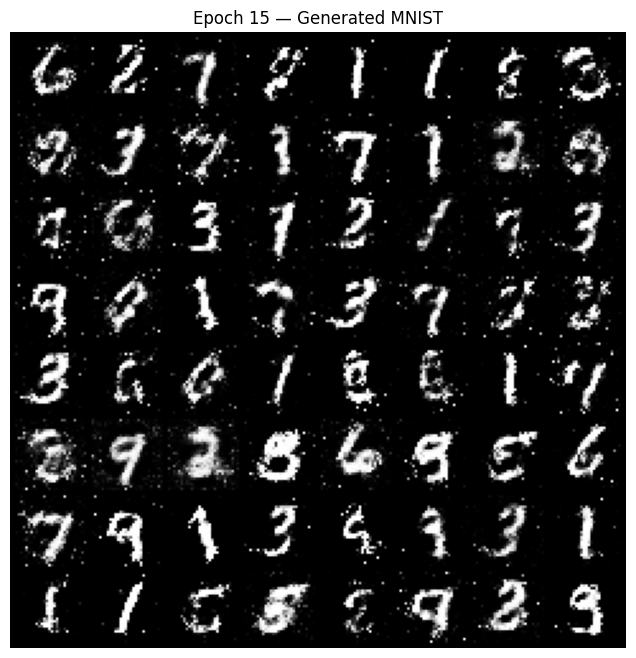

Epoch 15 | G: 1.426 | D: 0.951 | 6.8s


GAN Epoch 16/20: 100%|██████████| 469/469 [00:07<00:00, 64.12it/s]


Epoch 16 | G: 1.392 | D: 0.970 | 7.3s


GAN Epoch 17/20: 100%|██████████| 469/469 [00:06<00:00, 68.83it/s]


Epoch 17 | G: 1.373 | D: 0.978 | 6.8s


GAN Epoch 18/20: 100%|██████████| 469/469 [00:07<00:00, 63.70it/s]


Epoch 18 | G: 1.342 | D: 1.000 | 7.4s


GAN Epoch 19/20: 100%|██████████| 469/469 [00:06<00:00, 69.44it/s]


Epoch 19 | G: 1.337 | D: 0.996 | 6.8s


GAN Epoch 20/20: 100%|██████████| 469/469 [00:07<00:00, 66.98it/s]


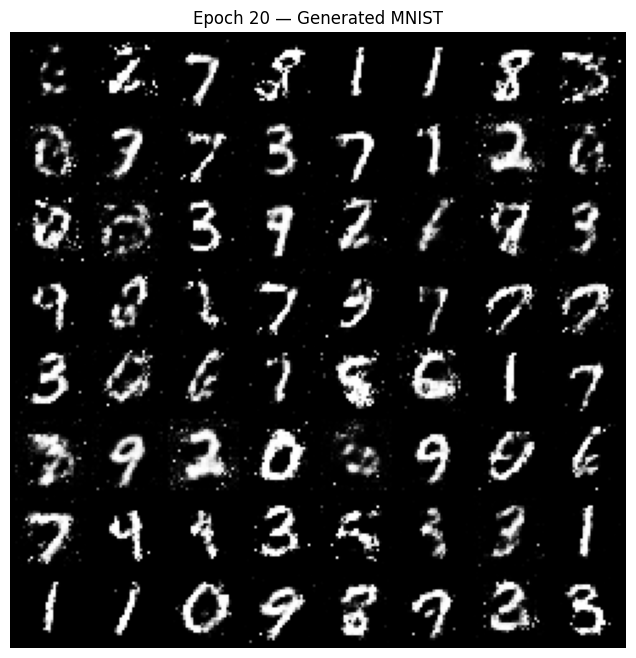

Epoch 20 | G: 1.322 | D: 1.011 | 7.0s


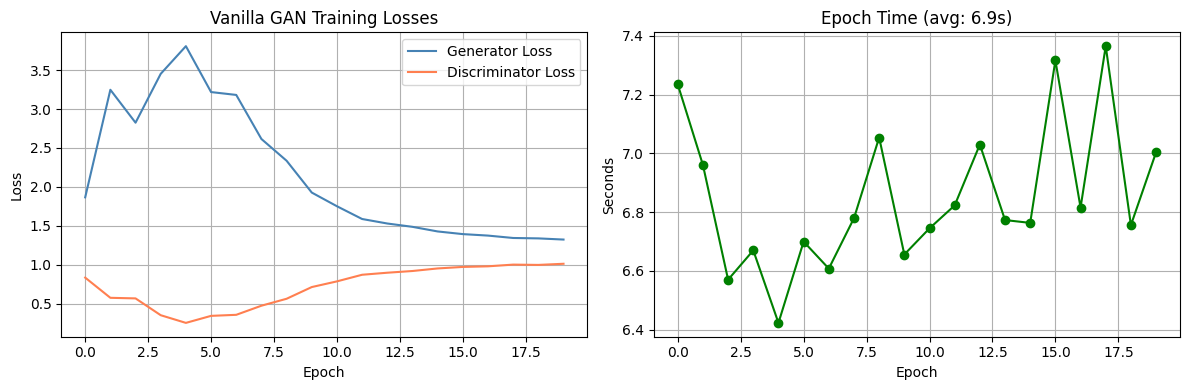

GAN checkpoint saved to /content/drive/MyDrive/AIT/RTML/A4-Generative-Models/saved/gan_mnist.pt


In [9]:
# --- GAN Training ---
GAN_EPOCHS = 20
g_losses, d_losses = [], []
gan_epoch_times = []

for epoch in range(GAN_EPOCHS):
    t0 = time.time()
    g_ep, d_ep = [], []
    for real_imgs, _ in tqdm(gan_loader, desc=f'GAN Epoch {epoch+1}/{GAN_EPOCHS}'):
        B = real_imgs.size(0)
        real_imgs = real_imgs.view(B, -1).to(device)
        real_labels = torch.ones(B, 1).to(device)
        fake_labels = torch.zeros(B, 1).to(device)

        # --- Train Discriminator ---
        z = torch.randn(B, Z_DIM).to(device)
        fake_imgs = G_gan(z).detach()
        d_loss = criterion(D_gan(real_imgs), real_labels) + criterion(D_gan(fake_imgs), fake_labels)
        opt_D.zero_grad();
        d_loss.backward();
        opt_D.step()

        # --- Train Generator ---
        z = torch.randn(B, Z_DIM).to(device)
        g_loss = criterion(D_gan(G_gan(z)), real_labels)
        opt_G.zero_grad();
        g_loss.backward();
        opt_G.step()

        g_ep.append(g_loss.item());
        d_ep.append(d_loss.item())

    ep_time = time.time() - t0
    gan_epoch_times.append(ep_time)
    g_losses.append(np.mean(g_ep))
    d_losses.append(np.mean(d_ep))
    if (epoch + 1) % 5 == 0:
        show_generated(G_gan, fixed_noise, epoch + 1)
    print(f"Epoch {epoch+1:02d} | G: {np.mean(g_ep):.3f} | D: {np.mean(d_ep):.3f} | {ep_time:.1f}s")

# Plot losses
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(g_losses, label='Generator Loss', color='steelblue')
axes[0].plot(d_losses, label='Discriminator Loss', color='coral')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Vanilla GAN Training Losses')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(gan_epoch_times, marker='o', color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Seconds')
axes[1].set_title(f'Epoch Time (avg: {np.mean(gan_epoch_times):.1f}s)')
axes[1].grid(True)
plt.tight_layout(); plt.show()

os.makedirs("saved", exist_ok=True)

torch.save(
    {
        "generator_state_dict": G_gan.state_dict(),
        "discriminator_state_dict": D_gan.state_dict(),
        "z_dim": Z_DIM,
        "generator_lr": 2e-4,
        "discriminator_lr": 2e-4,
        "epochs": GAN_EPOCHS,
    },
    "saved/gan_mnist.pt"
)

print("GAN checkpoint saved to /content/drive/MyDrive/AIT/RTML/A4-Generative-Models/saved/gan_mnist.pt")

## Mnist-Classifier

In [10]:
class MNISTClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

In [12]:
classifier = MNISTClassifier().to(device)

classifier_optimizer = torch.optim.Adam(
    classifier.parameters(),
    lr=1e-3
)

classifier_loss_fn = nn.CrossEntropyLoss()

CLASSIFIER_EPOCHS = 5

for epoch in range(CLASSIFIER_EPOCHS):
    classifier.train()

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(
        gan_loader,
        desc=f"Classifier Epoch {epoch + 1}/{CLASSIFIER_EPOCHS}"
    ):
        images = images.to(device)
        labels = labels.to(device)

        predictions = classifier(images)
        loss = classifier_loss_fn(predictions, labels)

        classifier_optimizer.zero_grad()
        loss.backward()
        classifier_optimizer.step()

        total_loss += loss.item()

        predicted_labels = predictions.argmax(dim=1)
        correct += (predicted_labels == labels).sum().item()
        total += labels.size(0)

    accuracy = 100 * correct / total

    print(
        f"Epoch {epoch + 1} | "
        f"Loss: {total_loss / len(gan_loader):.4f} | "
        f"Accuracy: {accuracy:.2f}%"
    )

torch.save(
    classifier.state_dict(),
    "saved/mnist_classifier.pt"
)

Classifier Epoch 1/5: 100%|██████████| 469/469 [00:06<00:00, 67.96it/s]


Epoch 1 | Loss: 0.2093 | Accuracy: 93.57%


Classifier Epoch 2/5: 100%|██████████| 469/469 [00:06<00:00, 68.58it/s]


Epoch 2 | Loss: 0.0546 | Accuracy: 98.32%


Classifier Epoch 3/5: 100%|██████████| 469/469 [00:06<00:00, 67.78it/s]


Epoch 3 | Loss: 0.0383 | Accuracy: 98.83%


Classifier Epoch 4/5: 100%|██████████| 469/469 [00:06<00:00, 67.20it/s]


Epoch 4 | Loss: 0.0283 | Accuracy: 99.11%


Classifier Epoch 5/5: 100%|██████████| 469/469 [00:06<00:00, 68.86it/s]

Epoch 5 | Loss: 0.0215 | Accuracy: 99.32%


In [16]:
checkpoint = torch.load(
    "saved/gan_mnist.pt",
    map_location=device
)

G_gan.load_state_dict(checkpoint["generator"])
G_gan.eval()

classifier.load_state_dict(
    torch.load(
        "saved/mnist_classifier.pt",
        map_location=device
    )
)
classifier.eval()

num_generated = 1000
all_predictions = []

with torch.no_grad():
    for start in range(0, num_generated, 100):
        current_batch_size = min(
            100,
            num_generated - start
        )

        noise = torch.randn(
            current_batch_size,
            Z_DIM,
            device=device
        )

        generated_images = G(noise)

        predictions = classifier(
            generated_images
        ).argmax(dim=1)

        all_predictions.append(
            predictions.cpu()
        )

all_predictions = torch.cat(all_predictions)

digit_counts = torch.bincount(
    all_predictions,
    minlength=10
)

print("Digit counts:")
for digit, count in enumerate(digit_counts):
    print(f"Digit {digit}: {count.item()}")

print("Total:", digit_counts.sum().item())

KeyError: 'generator'

---
## Part 2: CycleGAN — Unpaired Image-to-Image Translation

### The Problem with Paired GANs

Standard GANs require **paired training data** — for every input you need the exact target output. Collecting such pairs is expensive or impossible for most real tasks (photos ↔ paintings, horses ↔ zebras, dark hair ↔ blonde hair).

![Paired vs Unpaired](/content/drive/MyDrive/AIT/RTML/A4-Generative-Models/img/img_translation.JPG)

**CycleGAN** (Zhu et al., 2017) removes this requirement entirely by training two generators simultaneously:
- **G**: Domain X → Domain Y  (e.g., dark hair → blonde)
- **F**: Domain Y → Domain X  (e.g., blonde → dark hair)

### How CycleGAN Works

The key insight: if you translate an image X → Y → X, you should get back the original. This **cycle consistency** constraint forces the generators to learn meaningful translations without any paired examples.

![CycleGAN Architecture Overview](img/model1.jpg)

The full model has **two generators** and **two discriminators** — one for each domain:

![CycleGAN Full Model](img/model.jpg)

### The Three Loss Terms

**1. Adversarial Loss** — make generated images look realistic in the target domain:
$$\mathcal{L}_{adv} = \mathbb{E}_y[\log D_Y(y)] + \mathbb{E}_x[\log(1 - D_Y(G(x)))]$$

**2. Cycle Consistency Loss** — translating X→Y→X should recover the original:
$$\mathcal{L}_{cyc} = \mathbb{E}_x[\|F(G(x)) - x\|_1] + \mathbb{E}_y[\|G(F(y)) - y\|_1]$$

**3. Identity Loss** — G(y) ≈ y when y is already in the target domain (preserves color):
$$\mathcal{L}_{idt} = \mathbb{E}_y[\|G(y) - y\|_1] + \mathbb{E}_x[\|F(x) - x\|_1]$$

**Total loss:**
$$\mathcal{L} = \mathcal{L}_{adv}(G) + \mathcal{L}_{adv}(F) + \lambda_{cyc}\mathcal{L}_{cyc} + \lambda_{idt}\mathcal{L}_{idt}$$

The paper uses λ_cyc = 10, λ_idt = 5.

### Generator Architecture

The generator uses a ResNet-based encoder-decoder:

![CycleGAN Generator Architecture](img/Generator.jpg)

- **Encoder**: Conv7 → Downsample ×2 (stride-2 convolutions)
- **Transformer**: 6× Residual Blocks (preserve content)
- **Decoder**: Upsample ×2 → Conv7 + Tanh

Each residual block looks like:

![ResNet Block](img/Resnet.jpg)

> **Why InstanceNorm, not BatchNorm?** BatchNorm normalizes across the batch — forcing a shared mean/variance. For style transfer, each image should keep its own statistics. InstanceNorm normalizes per image, which is critical for CycleGAN.

### PatchGAN Discriminator

Instead of outputting a single scalar (real/fake for the whole image), PatchGAN outputs a **grid** — each element judges a 70×70 patch.

![PatchGAN Discriminator](img/discriminator.jpg)

This forces the discriminator to evaluate **local texture quality**, not just global composition → sharper, more realistic local details.

> **Why LSGAN (MSELoss) instead of BCE?** LSGAN penalizes outputs far from the decision boundary — it gives a gradient even when the discriminator is very confident. BCE gradients vanish when D outputs near 0 or 1. LSGAN is more stable for image translation.

### Our Setup: CelebA Faces

We use **CelebA** — 200k+ celebrity photos split by hair color:
- **Domain X** = dark hair (5,000 images)
- **Domain Y** = blonde hair (5,000 images)

The CycleGAN learns to swap hair colors without any paired examples.

![CycleGAN Results](img/Results.jpg)

![CycleGAN Teaser](img/cyclegan_teaser.jpg)

In [ ]:
# ============================================================
#  CelebA Dataset — download via torchvision
#  Two domains: dark hair (attr 9=0) vs blonde hair (attr 9=1)
# ============================================================

IMG_SIZE = 64  # use 64x64 to keep training tractable on CPU/single GPU

celeba_transform = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
])

torchvision.datasets.CelebA._check_integrity = lambda self: True

print("Downloading CelebA (this may take a few minutes on first run)...")
celeba_full = torchvision.datasets.CelebA(
    '/content/drive/MyDrive/AIT/RTML/A4-Generative-Models/data',
    split='train',
    target_type='attr',
    download=False,
    transform=celeba_transform
)

In [ ]:
# Split by hair color: attr index 9 = Blond_Hair
BLONDE_ATTR = 9

dark_indices   = [i for i, (_, attr) in enumerate(celeba_full) if attr[BLONDE_ATTR] == 0][:30000]
blonde_indices = [i for i, (_, attr) in enumerate(celeba_full) if attr[BLONDE_ATTR] == 1][:30000]

celeba_dark   = torch.utils.data.Subset(celeba_full, dark_indices)
celeba_blonde = torch.utils.data.Subset(celeba_full, blonde_indices)

loader_dark   = DataLoader(celeba_dark,   batch_size=16, shuffle=True,  num_workers=2, drop_last=True)
loader_blonde = DataLoader(celeba_blonde, batch_size=16, shuffle=True,  num_workers=2, drop_last=True)

print(f"Domain X (dark hair):   {len(celeba_dark)} images")
print(f"Domain Y (blonde hair): {len(celeba_blonde)} images")

Domain X (dark hair):   30000 images
Domain Y (blonde hair): 24267 images


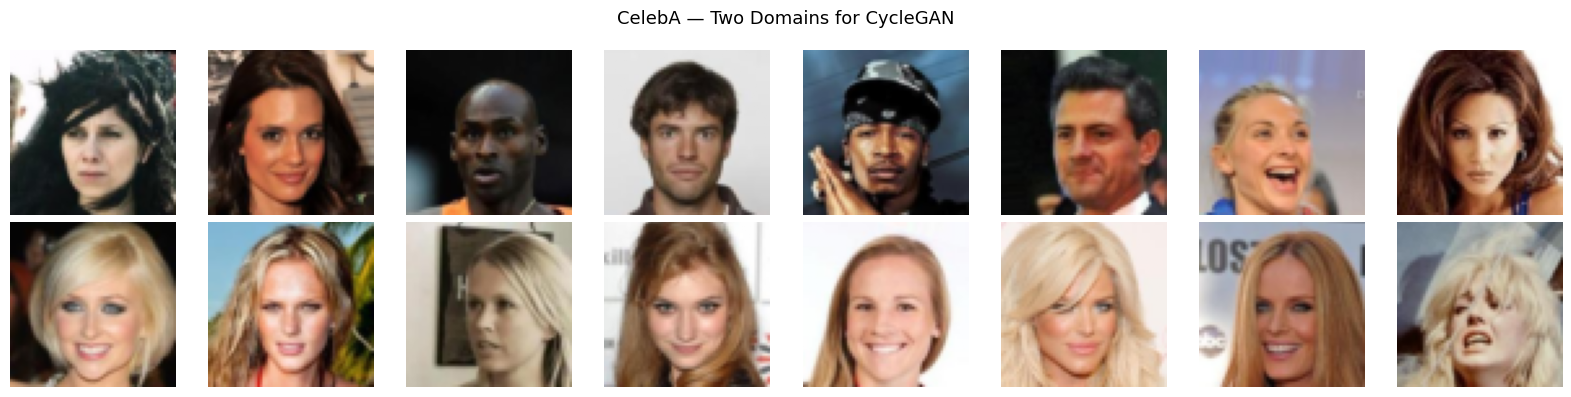

In [ ]:
# Show samples from both domains
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i, (imgs, _) in enumerate(DataLoader(celeba_dark,   batch_size=8, shuffle=True)):
    for j in range(8):
        axes[0, j].imshow(imgs[j].permute(1, 2, 0) * 0.5 + 0.5)
        axes[0, j].axis('off')
    break

for i, (imgs, _) in enumerate(DataLoader(celeba_blonde, batch_size=8, shuffle=True)):
    for j in range(8):
        axes[1, j].imshow(imgs[j].permute(1, 2, 0) * 0.5 + 0.5)
        axes[1, j].axis('off')
    break

axes[0, 0].set_ylabel('Dark Hair\n(Domain X)', fontsize=10)
axes[1, 0].set_ylabel('Blonde Hair\n(Domain Y)', fontsize=10)
plt.suptitle('CelebA — Two Domains for CycleGAN', fontsize=13)
plt.tight_layout();
plt.show()

In [ ]:
# ============================================================
#  CycleGAN Architecture
# ============================================================

class ResidualBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.ReflectionPad2d(1),
            nn.Conv2d(ch, ch, 3),
            nn.InstanceNorm2d(ch),
            nn.ReLU(inplace=True),
            nn.ReflectionPad2d(1),
            nn.Conv2d(ch, ch, 3),
            nn.InstanceNorm2d(ch),
        )
    def forward(self, x):
        return x + self.block(x)


class CycleGenerator(nn.Module):
    """ResNet generator for CycleGAN (64x64 images, 6 residual blocks)."""
    def __init__(self, in_ch=3, out_ch=3, ngf=64, n_res=6):
        super().__init__()
        layers = [
            nn.ReflectionPad2d(3),
            nn.Conv2d(in_ch, ngf, 7), nn.InstanceNorm2d(ngf), nn.ReLU(True),
            # Downsample x2
            nn.Conv2d(ngf,   ngf*2, 3, stride=2, padding=1), nn.InstanceNorm2d(ngf*2), nn.ReLU(True),
            nn.Conv2d(ngf*2, ngf*4, 3, stride=2, padding=1), nn.InstanceNorm2d(ngf*4), nn.ReLU(True),
        ]
        for _ in range(n_res):
            layers.append(ResidualBlock(ngf * 4))
        layers += [
            # Upsample x2
            nn.ConvTranspose2d(ngf*4, ngf*2, 3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(ngf*2), nn.ReLU(True),
            nn.ConvTranspose2d(ngf*2, ngf,   3, stride=2, padding=1, output_padding=1),
            nn.InstanceNorm2d(ngf), nn.ReLU(True),
            nn.ReflectionPad2d(3),
            nn.Conv2d(ngf, out_ch, 7), nn.Tanh(),
        ]
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class PatchDiscriminator(nn.Module):
    """PatchGAN discriminator: judges 70x70 patches as real/fake."""
    def __init__(self, in_ch=3, ndf=64):
        super().__init__()
        def block(in_c, out_c, norm=True):
            layers = [nn.Conv2d(in_c, out_c, 4, stride=2, padding=1)]
            if norm:
                layers.append(nn.InstanceNorm2d(out_c))
            layers.append(nn.LeakyReLU(0.2, inplace=True))
            return layers

        self.model = nn.Sequential(
            *block(in_ch, ndf, norm=False),
            *block(ndf,   ndf*2),
            *block(ndf*2, ndf*4),
            nn.ZeroPad2d(1),
            nn.Conv2d(ndf*4, 1, 4, padding=1),  # patch output
        )

    def forward(self, x):
        return self.model(x)


# Instantiate: G translates dark→blonde, F translates blonde→dark
G = CycleGenerator().to(device)  # X(dark) → Y(blonde)
F = CycleGenerator().to(device)  # Y(blonde) → X(dark)
D_X = PatchDiscriminator().to(device)  # judges dark hair images
D_Y = PatchDiscriminator().to(device)  # judges blonde hair images

# Count parameters
total_params = sum(p.numel() for p in G.parameters()) * 2 + \
               sum(p.numel() for p in D_X.parameters()) * 2
print(f"Generator params (each):     {sum(p.numel() for p in G.parameters()):,}")
print(f"Discriminator params (each): {sum(p.numel() for p in D_X.parameters()):,}")
print(f"Total trainable params:      {total_params:,}")

Generator params (each):     7,837,699
Discriminator params (each): 662,977
Total trainable params:      17,001,352


In [ ]:
# ============================================================
#  CycleGAN Training
# ============================================================

LAMBDA_CYC = 10.0  # cycle consistency weight
LAMBDA_IDT = 5.0   # identity loss weight
CYCLE_EPOCHS = 20  # increase to 50+ for better results

opt_G_all = torch.optim.Adam(
    list(G.parameters()) + list(F.parameters()), lr=2e-4, betas=(0.5, 0.999))
opt_D_all = torch.optim.Adam(
    list(D_X.parameters()) + list(D_Y.parameters()), lr=2e-4, betas=(0.5, 0.999))

adv_loss = nn.MSELoss()   # LSGAN: smoother gradients than BCE
cyc_loss = nn.L1Loss()

cycle_g_losses, cycle_d_losses = [], []
cycle_epoch_times = []

for epoch in range(CYCLE_EPOCHS):
    t0 = time.time()
    g_ep, d_ep = [], []

    dark_iter   = iter(loader_dark)
    blonde_iter = iter(loader_blonde)
    n_batches = min(len(loader_dark), len(loader_blonde))

    for _ in tqdm(range(n_batches), desc=f'CycleGAN Epoch {epoch+1}/{CYCLE_EPOCHS}', mininterval=5.0):
        real_x, _ = next(dark_iter)
        real_y, _ = next(blonde_iter)
        real_x, real_y = real_x.to(device), real_y.to(device)

        # ---- Train Generators G and F ----
        opt_G_all.zero_grad()

        fake_y  = G(real_x)          # dark -> blonde
        fake_x  = F(real_y)          # blonde -> dark
        cycle_x = F(fake_y)          # dark -> blonde -> dark
        cycle_y = G(fake_x)          # blonde -> dark -> blonde
        idt_x   = F(real_x)
        idt_y   = G(real_y)

        patch_shape = D_Y(fake_y).shape
        real_label  = torch.ones(patch_shape, device=device)
        fake_label  = torch.zeros(patch_shape, device=device)

        loss_G_adv = adv_loss(D_Y(fake_y), real_label) + adv_loss(D_X(fake_x), real_label)
        loss_cyc   = cyc_loss(cycle_x, real_x) + cyc_loss(cycle_y, real_y)
        loss_idt   = cyc_loss(idt_x, real_x)   + cyc_loss(idt_y, real_y)
        loss_G     = loss_G_adv + LAMBDA_CYC * loss_cyc + LAMBDA_IDT * loss_idt

        loss_G.backward()
        opt_G_all.step()

        # ---- Train Discriminators ----
        opt_D_all.zero_grad()

        loss_DX = adv_loss(D_X(real_x), real_label) + adv_loss(D_X(fake_x.detach()), fake_label)
        loss_DY = adv_loss(D_Y(real_y), real_label) + adv_loss(D_Y(fake_y.detach()), fake_label)
        loss_D  = (loss_DX + loss_DY) * 0.5

        loss_D.backward()
        opt_D_all.step()

        g_ep.append(loss_G.item())
        d_ep.append(loss_D.item())

    ep_time = time.time() - t0
    cycle_epoch_times.append(ep_time)
    cycle_g_losses.append(np.mean(g_ep))
    cycle_d_losses.append(np.mean(d_ep))
    print(f"Epoch {epoch+1:02d} | G: {np.mean(g_ep):.3f} | D: {np.mean(d_ep):.3f} | {ep_time:.1f}s")

torch.save({'G': G.state_dict(), 'F': F.state_dict()}, 'saved/cyclegan_celeba.pt')
print("Saved -> saved/cyclegan_celeba.pt")

CycleGAN Epoch 1/20: 100%|██████████| 1516/1516 [05:14<00:00,  4.82it/s]

Epoch 01 | G: 5.641 | D: 0.416 | 314.9s



CycleGAN Epoch 2/20: 100%|██████████| 1516/1516 [05:21<00:00,  4.72it/s]

Epoch 02 | G: 4.548 | D: 0.407 | 321.5s



CycleGAN Epoch 3/20: 100%|██████████| 1516/1516 [05:09<00:00,  4.89it/s]

...


CycleGAN Epoch 19/20: 100%|██████████| 1516/1516 [03:57<00:00,  6.38it/s]

Epoch 19 | G: 3.034 | D: 0.382 | 237.8s



CycleGAN Epoch 20/20: 100%|██████████| 1516/1516 [03:54<00:00,  6.46it/s]

Epoch 20 | G: 3.004 | D: 0.381 | 235.1s


RuntimeError: Parent directory saved does not exist.

In [ ]:
# ============================================================
#  CycleGAN Results -- Training Curves + Translation Grid
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(cycle_g_losses, label='Generator Loss', color='steelblue')
axes[0].plot(cycle_d_losses, label='Discriminator Loss', color='coral')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CycleGAN Training Losses')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(cycle_epoch_times, marker='o', color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Seconds')
axes[1].set_title(f'Epoch Time (avg: {np.mean(cycle_epoch_times):.1f}s)')
axes[1].grid(True)
plt.tight_layout(); plt.show()

# Show translations
ckpt = torch.load('saved/cyclegan_celeba.pt', map_location=device)
G.load_state_dict(ckpt['G']); F.load_state_dict(ckpt['F'])
G.eval(); F.eval()

def denorm(t):
    return (t * 0.5 + 0.5).clamp(0, 1)

with torch.no_grad():
    batch_x, _ = next(iter(DataLoader(celeba_dark,   batch_size=4, shuffle=True)))
    batch_y, _ = next(iter(DataLoader(celeba_blonde, batch_size=4, shuffle=True)))
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)
    fake_y = G(batch_x).cpu()
    fake_x = F(batch_y).cpu()

fig, axes = plt.subplots(4, 4, figsize=(10, 10))
row_labels = ['Real Dark', 'Dark -> Blonde', 'Real Blonde', 'Blonde -> Dark']
imgs_list  = [batch_x.cpu(), fake_y, batch_y.cpu(), fake_x]

for row in range(4):
    for col in range(4):
        axes[row, col].imshow(denorm(imgs_list[row][col]).permute(1, 2, 0))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(row_labels[row], fontsize=9)

plt.suptitle('CycleGAN -- Dark Hair <-> Blonde Hair Translation', fontsize=13)
plt.tight_layout(); plt.show()

G.train();
F.train()

### Test with Your Own Face!

Put a photo of yourself (or any face) in the notebook directory, name it `my_face.jpg`, then run the cell below. The trained CycleGAN will translate your hair color.

**Instructions:**
1. Add a face photo as `my_face.jpg` in the same folder as this notebook
2. The cell crops the center, resizes to 64×64, and runs it through both generators
3. You'll see: original → dark-to-blonde translation → blonde-to-dark translation

In [ ]:
# ============================================================
#  Test with Your Own Face
# ============================================================

face_path = 'my_face.jpg'  # <-- put your photo here

if not os.path.exists(face_path):
    print(f"File '{face_path}' not found.")
    print("Steps: add a photo named my_face.jpg to this folder, then re-run this cell.")
else:
    face_transform = transforms.Compose([
        transforms.CenterCrop(min(Image.open(face_path).size)),
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])
    ])

    img_pil = Image.open(face_path).convert('RGB')
    img_tensor = face_transform(img_pil).unsqueeze(0).to(device)

    ckpt = torch.load('saved/cyclegan_celeba.pt', map_location=device)
    G.load_state_dict(ckpt['G']); F.load_state_dict(ckpt['F'])
    G.eval(); F.eval()

    with torch.no_grad():
        to_blonde = G(img_tensor).squeeze(0).cpu()
        to_dark   = F(img_tensor).squeeze(0).cpu()

    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    titles = ['Original', 'G: → Blonde Hair', 'F: → Dark Hair']
    imgs   = [img_tensor.squeeze(0).cpu(), to_blonde, to_dark]
    for ax, title, img in zip(axes, titles, imgs):
        ax.imshow(denorm(img).permute(1, 2, 0))
        ax.set_title(title, fontsize=12)
        ax.axis('off')
    plt.suptitle('CycleGAN — Your Face', fontsize=14)
    plt.tight_layout(); plt.show()

    G.train();
    F.train()

---
## Part 3: DDPM — Denoising Diffusion Probabilistic Models

### Why Diffusion?

GANs produce sharp images but suffer from:
1. **Training instability** — the minimax game can oscillate or collapse
2. **Mode collapse** — G ignores parts of the data distribution

Ho et al. (NeurIPS 2020) asked: *"What if we model image generation as iterative denoising?"*

### Intuition: why destroy the image at all?

GAN and VAE both ask a network to go **directly** from noise/latent → finished image in one shot. That's a huge leap: the network has to invent global structure and fine detail simultaneously, with one forward pass, and no chance to "fix" an early mistake.

DDPM reframes generation as **many small, easy steps** instead of one hard step:

> "Think of it like sculpting from a rough block versus 3D-printing a statue in one shot. A sculptor doesn't carve the final statue in one stroke — they make thousands of tiny corrections, each easy to get right, each building on the last. DDPM does the same thing: instead of asking 'generate a perfect image from nothing,' it asks 'given something *almost* right, make it 1% better.' Repeat that 1,000 times and pure noise becomes a clean image."

There are two halves to this idea, and DDPM needs the first to be able to learn the second:

- **Forward Process — destroying the image (adding noise):** a fixed, mechanical recipe that gradually wrecks a clean image into pure noise. No learning here — it's just math. Its job is to manufacture an infinite supply of (clean, noisy) pairs at every "damage level," so the network has something to learn from.
- **Reverse Process — rebuilding the image (removing noise):** the part we actually train. A network looks at a noisy image and tries to undo *one step* of damage. Chain 1,000 of these small "undo" steps starting from pure noise, and a brand-new image emerges.

### Why predict the *noise*, not the image?

At each step the network could try to predict the clean image `x₀` directly, or it could predict just the noise `ε` that was added. DDPM predicts the noise, for a concrete reason:

> "`x₀` looks completely different depending on what digit/face/object it is — the target keeps changing shape. But `ε` is always just standard Gaussian noise, mean 0, regardless of what the image contains. That gives the network one consistent, simple target across every image and every timestep — much easier to learn than 'reconstruct an arbitrary image from a blend of signal and noise.' And since the forward formula below is linear, knowing `ε` is mathematically equivalent to knowing `x₀` anyway — so nothing is lost by predicting the easier quantity."

### The Two Processes

![DDPM Forward and Reverse Process](img/ddpm_process.png)

**Forward Process — destroying the image (adding noise) — fixed, not learned:** Gradually add Gaussian noise over T=1000 steps until the image becomes pure noise.

$$q(x_t \mid x_{t-1}) = \mathcal{N}(x_t;\; \sqrt{1-\beta_t}\, x_{t-1},\; \beta_t \mathbf{I})$$

**Shortcut (reparameterization):** Jump directly to any timestep `t`:

$$x_t = \sqrt{\bar{\alpha}_t}\, x_0 + \sqrt{1 - \bar{\alpha}_t}\, \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$

where $\bar{\alpha}_t = \prod_{s=1}^{t}(1-\beta_s)$ is the cumulative signal retention. This shortcut is what makes training fast: we don't need to simulate 1000 sequential noising steps — we jump straight to any `x_t` in one line, given the original image and a random `ε`.

**Reverse Process — rebuilding the image (removing noise) — learned:** A U-Net $\epsilon_\theta$ predicts the noise added at step `t` and subtracts it to recover `x_{t-1}`. This is the only part that's actually trained — the forward process above is pure math, no parameters.

**Training objective (surprisingly simple!):**

$$\mathcal{L} = \mathbb{E}_{t, x_0, \epsilon}\left[ \| \epsilon - \epsilon_\theta(x_t, t) \|^2 \right]$$

Just predict the noise. No adversarial game, no mode collapse.

![DDPM Training Algorithm](img/ddpm_training.png)

### The U-Net Denoiser

The U-Net takes two inputs: noisy image `x_t` + timestep `t` (sinusoidal embedding). Skip connections let the decoder reuse encoder features — critical for preserving fine details.

Why does it need `t` as an input? At `t=999` the image is almost pure noise — the network must make an aggressive correction. At `t=1` the image is almost clean — only a tiny correction is needed. The same network handles both extremes, so it needs to know *which* step it's currently undoing.

### The Noise Schedule

![Noise Schedule Comparison](img/noise_schedule.png)

The β schedule controls how fast we destroy the image. A **linear schedule** increases β from 1e-4 to 0.02. The **cosine schedule** (Nichol & Dhariwal, 2021) decays more gradually at the start, preserving more signal early on.

In [ ]:
# ====================================================
#  Part 3 — DDPM: Data + Noise Schedule
# ====================================================

# MNIST for DDPM (grayscale 28×28)
transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
mnist = torchvision.datasets.MNIST('./data', train=True, download=True, transform=transform_mnist)
mnist_loader = DataLoader(mnist, batch_size=128, shuffle=True, num_workers=2)

T = 1000  # total diffusion timesteps

def linear_beta_schedule(timesteps, beta_start=1e-4, beta_end=0.02):
    return torch.linspace(beta_start, beta_end, timesteps)

betas   = linear_beta_schedule(T).to(device)
alphas  = 1.0 - betas
alpha_bar = torch.cumprod(alphas, dim=0)  # ᾱ_t = ∏ α_1 ... α_t
sqrt_alpha_bar    = torch.sqrt(alpha_bar)
sqrt_one_minus_ab = torch.sqrt(1.0 - alpha_bar)

# Visualize the forward process
mnist_sample, _ = next(iter(DataLoader(mnist, batch_size=1, shuffle=True)))
img = mnist_sample[0].to(device)

fig, axes = plt.subplots(1, 7, figsize=(14, 2))
timesteps_to_show = [0, 100, 200, 400, 600, 800, 999]

for ax, t in zip(axes, timesteps_to_show):
    eps = torch.randn_like(img)
    noisy = sqrt_alpha_bar[t] * img + sqrt_one_minus_ab[t] * eps
    ax.imshow(noisy.squeeze().cpu().detach().numpy(), cmap='gray')
    ax.set_title(f't={t}')
    ax.axis('off')

plt.suptitle('Forward Process: Gradually adding noise', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
class SinusoidalEmbedding(nn.Module):
    """Encodes scalar timestep t into a fixed-size vector using sinusoidal frequencies."""
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(
            -torch.arange(half, device=t.device).float() * (torch.log(torch.tensor(10000.0)) / (half - 1))
        )
        args = t.float()[:, None] * freqs[None]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)


class ResBlock(nn.Module):
    """Residual block with timestep conditioning."""
    def __init__(self, in_ch, out_ch, time_dim):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.time_mlp = nn.Sequential(nn.SiLU(), nn.Linear(time_dim, out_ch))
        self.residual = nn.Conv2d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.norm1 = nn.GroupNorm(8, out_ch)
        self.norm2 = nn.GroupNorm(8, out_ch)

    def forward(self, x, t_emb):
        out1 = self.conv1(x)
        h = self.norm1(out1 * torch.sigmoid(out1))
        h = h + self.time_mlp(t_emb)[:, :, None, None]  # add time embedding
        out2 = self.conv2(h)
        h = self.norm2(out2 * torch.sigmoid(out2))
        return h + self.residual(x)


class SimpleUNet(nn.Module):
    """Lightweight U-Net for DDPM on MNIST."""
    def __init__(self, in_ch=1, base_ch=64, time_dim=256):
        super().__init__()
        self.time_embed = nn.Sequential(
            SinusoidalEmbedding(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )
        # Encoder
        self.enc1 = ResBlock(in_ch, base_ch, time_dim)
        self.enc2 = ResBlock(base_ch, base_ch*2, time_dim)
        self.down  = nn.MaxPool2d(2)
        # Bottleneck
        self.bot   = ResBlock(base_ch*2, base_ch*4, time_dim)
        # Decoder
        self.up    = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.dec2  = ResBlock(base_ch*4 + base_ch*2, base_ch*2, time_dim)
        self.dec1  = ResBlock(base_ch*2 + base_ch, base_ch, time_dim)
        self.out   = nn.Conv2d(base_ch, in_ch, 1)

    def forward(self, x, t):
        t_emb = self.time_embed(t)
        # Encode
        e1 = self.enc1(x, t_emb)          # (B, 64, 28, 28)
        e2 = self.enc2(self.down(e1), t_emb)  # (B, 128, 14, 14)
        # Bottleneck
        b  = self.bot(self.down(e2), t_emb)   # (B, 256, 7, 7)
        # Decode with skip connections
        d2 = self.dec2(torch.cat([self.up(b), e2], dim=1), t_emb)   # (B, 128, 14, 14)
        d1 = self.dec1(torch.cat([self.up(d2), e1], dim=1), t_emb)  # (B, 64, 28, 28)
        return self.out(d1)  # predict noise ε, same shape as input

## DDPM Step 3: Training

The training loop is elegant:
1. Sample a clean image `x_0` and a random timestep `t`
2. Add noise to get `x_t` using the shortcut formula
3. Ask the U-Net to predict the noise `ε` that was added
4. Loss = MSE(predicted noise, actual noise)

That's all! No adversarial game, no posterior collapse — just simple regression.

In [ ]:
import torch.nn.functional as F

unet = SimpleUNet().to(device)
opt_ddpm = torch.optim.Adam(unet.parameters(), lr=2e-4)
print(f'U-Net parameters: {sum(p.numel() for p in unet.parameters()):,}')


def q_sample(x0, t, noise=None):
    """Forward process: add noise to x0 at timestep t."""
    if noise is None:
        noise = torch.randn_like(x0)
    return sqrt_alpha_bar[t][:, None, None, None] * x0 + \
           sqrt_one_minus_ab[t][:, None, None, None] * noise


DDPM_EPOCHS = 10  # increase to 50+ for good results
ddpm_losses = []

for epoch in range(DDPM_EPOCHS):
    unet.train()
    ep_loss = []
    for x0, _ in tqdm(mnist_loader, desc=f'DDPM Epoch {epoch+1}/{DDPM_EPOCHS}'):
        x0 = x0.to(device)
        B  = x0.size(0)

        # Sample random timesteps for each image in batch
        t = torch.randint(0, T, (B,), device=device)

        # Add noise (forward process)
        noise  = torch.randn_like(x0)
        x_t    = q_sample(x0, t, noise)

        # Predict the noise
        pred_noise = unet(x_t, t)

        # Simple MSE loss on noise prediction (Changed from F.mse_loss to func.mse_loss)
        loss = F.mse_loss(pred_noise, noise)

        opt_ddpm.zero_grad()
        loss.backward()
        opt_ddpm.step()
        ep_loss.append(loss.item())

    ddpm_losses.append(np.mean(ep_loss))
    print(f'Epoch {epoch+1:03d} | Loss: {np.mean(ep_loss):.4f}')

torch.save(unet.state_dict(), 'saved/ddpm_mnist.pt')

plt.figure(figsize=(8, 4))
plt.plot(ddpm_losses, marker='o', color='orange')
plt.title('DDPM Training Loss')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.grid(True); plt.show()

## DDPM Step 4: Sampling (Generation)

To generate a new image:
1. Start with pure Gaussian noise `x_T`
2. Apply the U-Net 1000 times in reverse, each time subtracting a predicted noise
3. The image gradually becomes cleaner

The reverse step formula:

$$x_{t-1} = \frac{1}{\sqrt{\alpha_t}} \left( x_t - \frac{\beta_t}{\sqrt{1 - \bar{\alpha}_t}} \epsilon_\theta(x_t, t) \right) + \sigma_t z, \quad z \sim \mathcal{N}(0, I)$$

![DDPM Sampling Process](img/ddpm_sampling.png)

In [ ]:
unet.load_state_dict(torch.load('saved/ddpm_mnist.pt', map_location=device))
unet.eval()

# Precompute values for reverse process
sqrt_recip_alphas     = torch.sqrt(1.0 / alphas)
posterior_variance    = betas * (1.0 - F.pad(alpha_bar[:-1], (1, 0), value=1.0)) / (1.0 - alpha_bar)


@torch.no_grad()
def p_sample(x_t, t_scalar):
    """One reverse diffusion step: x_t → x_{t-1}."""
    t_batch = torch.full((x_t.size(0),), t_scalar, device=device, dtype=torch.long)
    pred_noise = unet(x_t, t_batch)

    # Compute mean of reverse process
    coeff = betas[t_scalar] / sqrt_one_minus_ab[t_scalar]
    mean  = sqrt_recip_alphas[t_scalar] * (x_t - coeff * pred_noise)

    if t_scalar == 0:
        return mean
    noise = torch.randn_like(x_t)
    return mean + torch.sqrt(posterior_variance[t_scalar]) * noise


@torch.no_grad()
def generate(n_samples=64):
    """Full generation: start from noise, run T reverse steps."""
    x = torch.randn(n_samples, 1, 28, 28).to(device)
    for t in tqdm(reversed(range(T)), total=T, desc='Sampling'):
        x = p_sample(x, t)
    return x


samples = generate(64)
grid = torchvision.utils.make_grid(samples, nrow=8, normalize=True)
plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).cpu())
plt.title('DDPM Generated MNIST Samples')
plt.axis('off');
plt.show()

## Visualize the Denoising Process

Let's watch the reverse process in action — from pure noise to a digit.

In [ ]:
@torch.no_grad()
def generate_with_trajectory(n_samples=8):
    """Generate images and record snapshots along the way."""
    x = torch.randn(n_samples, 1, 28, 28).to(device)
    snapshots = []
    show_at = {999, 800, 600, 400, 200, 100, 50, 0}
    for t in reversed(range(T)):
        x = p_sample(x, t)
        if t in show_at:
            snapshots.append((t, x.cpu().clone()))
    return snapshots


snapshots = generate_with_trajectory(8)
fig, axes = plt.subplots(8, len(snapshots), figsize=(len(snapshots)*1.5, 12))

for col, (t, imgs) in enumerate(snapshots):
    for row in range(8):
        ax = axes[row][col]
        ax.imshow(imgs[row].squeeze().numpy(), cmap='gray')
        ax.axis('off')
        if row == 0:
            ax.set_title(f't={t}', fontsize=9)

plt.suptitle('Reverse Diffusion Process: Noise → Digit', fontsize=13)
plt.tight_layout();
plt.show()

---
# Exercises

## 1. GAN Mode Collapse

Mode collapse occurs when the generator produces only a few types of outputs, ignoring most of the data distribution.

a) After training the Vanilla GAN, generate 1000 images and classify them using a pretrained MNIST classifier. Fill in the table:

| Digit | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| Count (out of 1000) | ? | ? | ? | ? | ? | ? | ? | ? | ? | ? |

Plot a bar chart of the distribution. Does your GAN cover all 10 digits evenly?

b) Intentionally cause mode collapse: set the discriminator learning rate to 6e-4 (3× default). Report the table from (a) again after collapse. Which digits vanish?

c) Describe two techniques that help prevent mode collapse (from your lecture notes on WGAN or minibatch discrimination).

---

## 2. CycleGAN Ablation — Cycle Consistency

The cycle consistency loss is what makes CycleGAN work without paired data.

a) Re-train with `LAMBDA_CYC = 0` (disabled) for 10 epochs. Compare the translation quality:

| Setting | Visual quality | Face structure preserved? | Notes |
|---|---|---|---|
| λ_cyc = 10 (default) | ? | ? | ? |
| λ_cyc = 0 | ? | ? | ? |

b) Show 4 example translations from each setting. What artifacts appear when cycle loss is removed?

c) Explain in 2–3 sentences: why does removing cycle consistency cause the generator to "cheat"?

---

## 3. Your Own Face — Style Transfer

Run the "Test with Your Own Face" cell with your own photo (`my_face.jpg`).

a) Include a screenshot: `[original | dark→blonde | blonde→dark]`

b) Did the model preserve your face structure (eyes, nose, background)? Explain with reference to the loss terms.

c) The model was trained on CelebA celebrities. If your photo is very different from the training distribution (different lighting, ethnicity, age), what do you expect — and did you observe it?

---

## 4 DDPM Noise Schedule Ablation

The noise schedule determines how quickly the image is destroyed during the forward process.

a) Implement the **cosine schedule** (Nichol & Dhariwal, 2021) and compare with linear:

```python
def cosine_beta_schedule(timesteps, s=0.008):
    t = torch.linspace(0, timesteps, timesteps + 1)
    alphas_bar = torch.cos(((t / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_bar = alphas_bar / alphas_bar[0]
    betas = 1 - (alphas_bar[1:] / alphas_bar[:-1])
    return torch.clamp(betas, 0.0001, 0.9999)
```

b) Plot both ᾱ_t curves side by side. Fill in the table:

| Schedule | Loss at epoch 10 | Visual quality (1–5) | Notes |
|---|---|---|---|
| Linear | ? | ? | ? |
| Cosine | ? | ? | ? |

c) Train with both schedules and show a grid of 64 generated samples for each. Which looks better, and why does the cosine schedule preserve signal longer at the start?

---

## Submission

Submit your work to GitHub. Your repository should contain:

### 1. Training Script (`run.py`)

```bash
# Train Vanilla GAN on MNIST
python3 run.py --model gan      --dataset mnist   --epochs 20 --train

# Train CycleGAN on CelebA
python3 run.py --model cyclegan --dataset celeba  --epochs 20 --train

# Train DDPM on MNIST
python3 run.py --model ddpm     --dataset mnist   --epochs 20 --train

# Test CycleGAN with your own face
python3 run.py --model cyclegan --weights saved/cyclegan_celeba.pt --test-image my_face.jpg

# DDPM with cosine schedule (Exercise 4)
python3 run.py --model ddpm     --dataset mnist   --epochs 20 --schedule cosine --train

# Generate DDPM samples
python3 run.py --model ddpm     --weights saved/ddpm_mnist.pt --generate --n 64
```

### 2. `README.md`

Your `README.md` must include:

**Commands used** (exact commands you ran)

**Results table:**

| Model | Dataset | Visual Quality | Training Time | Notes |
|---|---|---|---|---|
| Vanilla GAN | MNIST | ? | ? | mode collapse check |
| CycleGAN | CelebA | ? | ? | dark↔blonde |
| DDPM (linear) | MNIST | ? | ? | baseline |
| DDPM (cosine) | MNIST | ? | ? | schedule ablation |

**Visualizations** (include in README):
- Generated MNIST grid (GAN)
- CycleGAN translation grid: real dark | →blonde | real blonde | →dark
- Your own face result (3-panel: original | →blonde | →dark)
- DDPM denoising trajectory (noise → digit)
- Noise schedule comparison plot (ᾱ_t linear vs cosine)
- Mode collapse histogram (Exercise 1a)

**Discussion** (3–5 sentences): Based on your experiments, when would you use a GAN vs CycleGAN vs Diffusion for a real-world image synthesis task?